# PDE test cases

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc
from archimedes.experimental.approximation import (
    ConcatBasis,
    ConstrainedBasis,
    FunctionSpace,
    LagrangeBasis,
    OrthogonalPolynomialBasis,
)
from archimedes.measure import LegendreMeasure, UnitInterval
from archimedes.quadrature import quadint

## Problem A: nonlinear spectral Galerkin BVP

$$-u''(x) + u(x)^3 = f(x), \qquad x \in [-1, 1], \qquad u(-1) = u(1) = 0$$

on a global Legendre basis. To check the discretization against something exact, we
pick a manufactured solution $u(x) = 1 - x^2$ and solve for the forcing $f$ that
makes it exact: $f = -u'' + u^3 = 2 + (1-x^2)^3$. A correct solver should recover
$u(x) = 1-x^2$ to (near) machine precision, since it's a degree-2 polynomial and
therefore exactly representable in the basis.

The basis is modal, so `boundary_dofs()` is `(None, None)` -- there's no coefficient
that *is* a boundary value. We use the tau method instead: test the strong-form
residual against every mode via `space_a.basis_matrix().T @ r(x)`, then overwrite the
two highest-degree mode equations with the Dirichlet constraints, evaluated directly
through `u(x_bc)`.

In [2]:
n_basis = 12
space_a = FunctionSpace.legendre(n_basis, a=-1.0, b=1.0)

print("boundary_dofs() for a modal basis:", space_a.basis.boundary_dofs())


def u_exact_a(x):
    return 1 - x**2


def f_manufactured_a(x):
    u_pp = -2 * np.ones_like(x)
    return -u_pp + u_exact_a(x) ** 3

boundary_dofs() for a modal basis: (None, None)


In [3]:
Phi = space_a.basis_matrix()
x = Phi.nodes
u0_a = space_a.function()

def residual_a(c):
    u = u0_a.replace(coefficients=c)

    # Evaluate the residual at the quadrature nodes (pointwise expression)
    r_val = -u(x, deriv=2) + u(x) ** 3 - f_manufactured_a(x)

    # Galerkin projection of the residual onto the basis functions, giving the
    # coefficients of the residual vector.
    r = Phi.T @ r_val

    # Tau method: replace the top two (highest-mode) equations with the BCs.
    r[-1] = u(np.array([1.0]))[0]
    r[-2] = u(np.array([-1.0]))[0]
    return r


c0_a = u0_a.coefficients
c_sol_a = arc.optimize.root(residual_a, c0_a)
u_sol_a = u0_a.replace(coefficients=c_sol_a)

x_check_a = np.linspace(-1, 1, 9)
err_a = np.max(np.abs(u_sol_a(x_check_a) - u_exact_a(x_check_a)))
print(f"max |u_h - u_exact| on check grid: {err_a:.3e}")

max |u_h - u_exact| on check grid: 1.050e-13


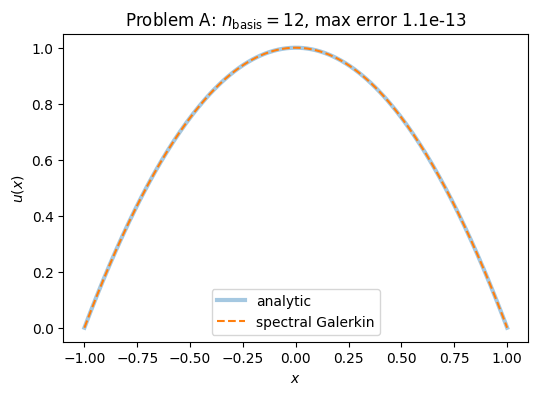

In [4]:
x_plot_a = np.linspace(-1, 1, 200)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(x_plot_a, u_exact_a(x_plot_a), lw=3, alpha=0.4, label="analytic")
ax.plot(x_plot_a, u_sol_a(x_plot_a), "--", label="spectral Galerkin")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x)$")
ax.set_title(f"Problem A: $n_{{\\mathrm{{basis}}}}={n_basis}$, max error {err_a:.1e}")
ax.legend()
plt.show()

## Problem B: nonlinear FEM Poisson

$$-\big((1+u(x)^2)\,u'(x)\big)' = f(x), \qquad x \in [0, 1], \qquad u(0) = u(1) = 0$$

on a `PiecewiseBasis` of quadratic Lagrange elements with $C^0$ continuity. Piecewise
polynomial elements don't have a meaningful strong-form second derivative at element
boundaries, so this is discretized in *weak* (variational) form via integration by
parts: multiply by a test function $v$ and integrate,

$$\int (1+u^2)\,u'\,v'\,dx = \int f\,v\,dx,$$

which is exactly `space_b.basis_matrix(deriv=1).T @ r(x)` on both sides -- testing
against the *derivative* of the basis rather than the basis itself, since the
derivative is what survived the integration by parts.

Manufactured solution: $u(x) = x(1-x)$, giving
$f(x) = -\big[2u\,(u')^2 + (1+u^2)\,u''\big]$ with $u'=1-2x$, $u''=-2$.

Unlike Problem A, this basis is nodal: `boundary_dofs()` (just fixed on
`PiecewiseBasis` -- it previously always returned `(None, None)`, even under
`continuity=0` with an element basis that has well-defined endpoint DOFs) gives the
exact global coefficient indices for $u(0)$ and $u(1)$, so Dirichlet is a direct row
replacement, no tau-style bookkeeping required.

In [ ]:
breakpoints = np.linspace(0.0, 1.0, 11)  # 10 elements
space_b = FunctionSpace.piecewise("lagrange", 2, breakpoints)  # quadratic

left, right = space_b.basis.boundary_dofs()
print(f"boundary_dofs() for the tiled/assembled basis: ({left}, {right})")
print(f"n_basis = {space_b.n_basis}")


def u_exact_b(x):
    return x * (1 - x)


def k_coef(u):
    return 1 + u**2


def f_manufactured_b(x):
    u = u_exact_b(x)
    u_p = 1 - 2 * x
    u_pp = -2 * np.ones_like(x)
    return -(2 * u * u_p**2 + k_coef(u) * u_pp)

In [6]:
Phi = space_b.basis_matrix()
dPhi = space_b.basis_matrix(deriv=1)
x = Phi.nodes
u0_b = space_b.function()

def residual_b(c):
    u = u0_b.replace(coefficients=c)

    # Evaluate the residual at the quadrature nodes (pointwise expression)
    # and then project onto the test functions (Galerkin projection) to
    # get the residual coefficients.
    lhs = dPhi.T @ (k_coef(u(x)) * u(x, deriv=1))
    rhs = Phi.T @ f_manufactured_b(x)
    r = lhs - rhs
    # Essential (Dirichlet) BCs: the boundary DOF's coefficient *is* the value.
    r[left] = c[left] - 0.0
    r[right] = c[right] - 0.0
    return r


c0_b = np.zeros(space_b.n_basis)
c_sol_b = arc.optimize.root(residual_b, c0_b)
u_sol_b = u0_b.replace(coefficients=c_sol_b)

x_check_b = np.linspace(0, 1, 11)
err_b = np.max(np.abs(u_sol_b(x_check_b) - u_exact_b(x_check_b)))
print(f"max |u_h - u_exact| on check grid: {err_b:.3e}")

max |u_h - u_exact| on check grid: 5.551e-17


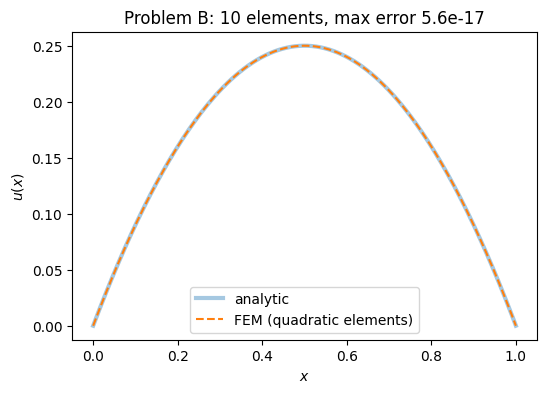

In [7]:
x_plot_b = np.linspace(0, 1, 200)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(x_plot_b, u_exact_b(x_plot_b), lw=3, alpha=0.4, label="analytic")
ax.plot(x_plot_b, u_sol_b(x_plot_b), "--", label="FEM (quadratic elements)")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x)$")
ax.set_title(f"Problem B: {space_b.basis.n_elements} elements, max error {err_b:.1e}")
ax.legend()
plt.show()

## Problem C: a stress test for the BC layer

$$-u''(x) + u(x)^2 = f(x), \qquad x \in [-1, 1], \qquad u'(-1) = g_L, \qquad
\int_{-1}^1 u(x)\,dx = 0$$

Problems A and B were "deliberately similar in structure" (per the intro) so that
the *basis* dispatch (modal vs. nodal) could be compared directly -- but that also
means they share exactly one BC topology: two Dirichlet conditions, one per
endpoint. That's the only shape `boundary_dofs()` (a left/right pair) and
`apply_bcs()` (one condition per end, replacing that end's row) were ever tested
against. This problem is chosen to be structurally different in exactly the way that
matters here, rather than just cosmetically:

- **`u'(-1) = g_L` is a Neumann condition**, not a value -- `DirichletBC`'s `deriv`
  field can express it, but it isn't a value at a `boundary_dofs()` slot.
- **The zero-mean constraint isn't associated with an endpoint at all.** It's a
  global integral over the whole domain. There is no "which end does this belong to"
  question to ask `boundary_dofs()` -- it doesn't have a slot for this by
  construction, not by omission.

(A 4th-order operator -- needing two conditions per end -- would be a cleaner
demonstration of `boundary_dofs()`'s 2-tuple shape specifically breaking, but that
needs a Hermite-type basis with derivative DOFs, which isn't implemented yet. This
problem instead stresses the *other* assumption `apply_bcs()` makes: that every
condition is *some* value at *some* point.)

Manufactured solution $u(x) = x^3 + x^2 - 2x - \tfrac13$ has zero mean on $[-1, 1]$
(the odd terms integrate to zero by symmetry, and $x^2 - \tfrac13$ was chosen
specifically so its mean is zero too), and $u'(-1) = -1$, giving $g_L = -1$ and
$f(x) = -(6x + 2) + u(x)^2$.

In [8]:
n_basis_c = 12
space_c = FunctionSpace.legendre(n_basis_c, a=-1.0, b=1.0)

g_left = -1.0  # u'(-1)


def u_exact_c(x):
    return x**3 + x**2 - 2 * x - 1 / 3


def f_manufactured_c(x):
    u_pp = 6 * x + 2
    return -u_pp + u_exact_c(x) ** 2
    

Phi = space_c.basis_matrix()
x = Phi.nodes
u0_c = space_c.function()

def residual_c(c):
    u = u0_c.replace(coefficients=c)

    # Evaluate the residual at the quadrature nodes (pointwise expression)
    r_val = -u(x, deriv=2) + u(x) ** 2 - f_manufactured_c(x)

    # Galerkin projection of the residual onto the basis functions, giving the
    # coefficients of the residual vector.
    r = Phi.T @ r_val

    # Neither condition is a `boundary_dofs()` value, so there's no dispatch
    # to reuse -- borrow the top two (tau) rows directly by hand.
    r[-1] = u(np.array([-1.0]), deriv=1)[0] - g_left
    r[-2] = u.integrate(-1.0, 1.0)  # zero-mean constraint
    return r


c0_c = np.zeros(space_c.n_basis)
c_sol_c = arc.optimize.root(residual_c, c0_c)
u_sol_c = u0_c.replace(coefficients=c_sol_c)

x_check_c = np.linspace(-1, 1, 9)
err_c = np.max(np.abs(u_sol_c(x_check_c) - u_exact_c(x_check_c)))
print(f"max |u_h - u_exact| on check grid: {err_c:.3e}")

max |u_h - u_exact| on check grid: 6.106e-16


In [9]:
x_c, w_c = space_c.quadrature()
via_dot = np.dot(w_c, u_sol_c(x_c))
via_integral = quadint(u_sol_c, -1.0, 1.0)
print(
    f"zero mean, np.dot(w, u(x)) vs. quadint(u, -1, 1): {via_dot:.3e} vs. {via_integral:.3e}"
)

zero mean, np.dot(w, u(x)) vs. quadint(u, -1, 1): -8.327e-17 vs. -7.286e-16


## Sturm-Liouville eigenvalue problem

$$-u''(x) = \lambda\, u(x), \qquad x \in [-1, 1], \qquad u(-1) = u(1) = 0$$

A linear eigenvalue problem; once we discretize into the form

$$
K u_n = \lambda_n M u_n
$$

then we can use `scipy.linalg.eig` for the generalized (mass/stiffness) matrix pencil does. The analytic spectrum is known exactly, $\lambda_n = (n\pi/2)^2$ with $u_n(x) = \sin(n\pi(x+1)/2)$, so every discretization below can be checked
against it directly.

This particular problem is used by Boyd to exemplify a failure mode of row-replacement: spurious infinite eigenvalues associated with the boundary conditions.

Instead we 

In [10]:
n_basis = 12


def lambda_exact(n):
    return (n * np.pi / 2) ** 2


n_modes = np.arange(1, 7)
print("analytic lambda_n = (n*pi/2)^2:", lambda_exact(n_modes))

analytic lambda_n = (n*pi/2)^2: [ 2.4674011   9.8696044  22.2066099  39.4784176  61.68502751 88.82643961]


Strong-form residual evaluated directly on the modal basis, no integration by parts:

$K_{ij} = \int \phi_i\,(-\phi_j'')\,dx$, $M_{ij} = \int \phi_i\,\phi_j\,dx$.

However, the trial/test space is the `(n-2)`-dimensional Dirichlet-satisfying subspace directly - every basis function already vanishes at $\pm 1$, so there is no BC row to add or replace.

In [11]:
from scipy import linalg

legendre_basis = OrthogonalPolynomialBasis(LegendreMeasure(), n_basis)
bubble = ConstrainedBasis.dirichlet(legendre_basis)
space_bubble = FunctionSpace(bubble, UnitInterval.Parameters(a=-1.0, b=1.0))

Phi_b = space_bubble.basis_matrix()
d2Phi_b = space_bubble.basis_matrix(deriv=2)
K_b = Phi_b.T @ (-d2Phi_b.matrix)
M_b = Phi_b.T @ Phi_b

eigvals_b = np.sort(linalg.eig(K_b, M_b, right=False).real)
print(f"{bubble.n_basis} eigenvalues")
print(eigvals_b)
print()
print("error vs analytic (first 6):")
print(np.abs(eigvals_b[:6] - lambda_exact(n_modes)))

10 eigenvalues
[  2.4674011    9.8696044   22.20661234  39.47850459  61.76067929
  89.16437778 132.9179639  181.6871226  463.14734337 642.30039063]

error vs analytic (first 6):
[1.28785871e-14 4.49773552e-12 2.44177672e-06 8.69849598e-05
 7.56517828e-02 3.37938174e-01]


## Euler-Bernoulli beam bending

$$EI\, u''''(x) = q(x), \qquad x \in [0, L]$$

the classical Euler-Bernoulli beam equation (with $EI=1$). Every problem so far has been 2nd order; this is the first 4th-order operator, and it needs $C^1$ continuity (value *and* slope shared between elements) which is exactly what `CubicHermiteBasis` was built for (`FunctionSpace.piecewise(kind="hermite", ..., continuity=1)`).

Rather than manufacturing a forcing for an arbitrary solution, we use the classical cantilever beam under a tip load: clamped at $x=0$ ($u(0)=u'(0)=0$) and free at $x=L$ with an applied tip shear ($u''(L)=0$, no applied moment; $u'''(L)=P$, the tip shear) and no distributed load ($q=0$). The exact solution is the textbook cubic $u(x) = \tfrac{P}{6}x^3 - \tfrac{PL}{2}x^2$ -- degree 3, so (unlike a quartic, which a piecewise-*cubic* space could only approximate) it's exactly representable by piecewise cubic Hermite elements regardless of how many elements there are, since a global cubic restricted to any sub-element is still a cubic.

The weak form (two integrations by parts) is
$$\int_0^L u''\,v''\,dx = \int_0^L q\,v\,dx - \big[u'''v\big]_0^L + \big[u''v'\big]_0^L,$$
and since $v(0)=v'(0)=0$ (test functions satisfy the homogeneous clamped condition too), only the $x=L$ terms survive: $-P\,v(L)$ (using $u'''(L)=P$, $u''(L)=0$, $q=0$).

This is the first problem to use `boundary_dofs(order=1)` -- the slope DOF -- for a genuine essential condition (alongside `boundary_dofs(order=0)` for the value), *and* a natural condition that lands on a single equation because Hermite shape functions are cardinal at the nodes: only the right end's *value* DOF is nonzero at $x=L$, so the tip load contributes to exactly one row.

In [ ]:
L = 1.0
P = 6.0  # prescribed tip shear u'''(L)

breakpoints_d = np.linspace(0.0, L, 5)  # 4 cubic Hermite elements
space_d = FunctionSpace.piecewise("hermite", 3, breakpoints_d, continuity=1)

left0, right0 = space_d.basis.boundary_dofs(order=0)  # value DOFs
left1, right1 = space_d.basis.boundary_dofs(order=1)  # slope DOFs
print(f"value DOFs: ({left0}, {right0}), slope DOFs: ({left1}, {right1})")


def u_exact_d(x):
    return (P / 6) * x**3 - (P * L / 2) * x**2


d2Phi = space_d.basis_matrix(deriv=2)
K_d = d2Phi.T @ d2Phi  # stiffness matrix, int u'' v'' dx
u0_d = space_d.function()


def residual_d(c):
    r = K_d @ c

    # Natural BC: tip shear u'''(L) = P shows up only in the right end's
    # value-DOF row, since Hermite shape functions are cardinal at the nodes.
    r[right0] = r[right0] + P

    # Essential BCs: clamped at x=0 -- value *and* slope, both genuine DOF slots.
    r[left0] = c[left0] - 0.0
    r[left1] = c[left1] - 0.0
    return r


c0_d = np.zeros(space_d.n_basis)
c_sol_d = arc.optimize.root(residual_d, c0_d)
u_sol_d = u0_d.replace(coefficients=c_sol_d)

x_check_d = np.linspace(0, L, 100)
err_d = np.max(np.abs(u_sol_d(x_check_d) - u_exact_d(x_check_d)))
print(f"max |u_h - u_exact| on check grid: {err_d:.3e}")

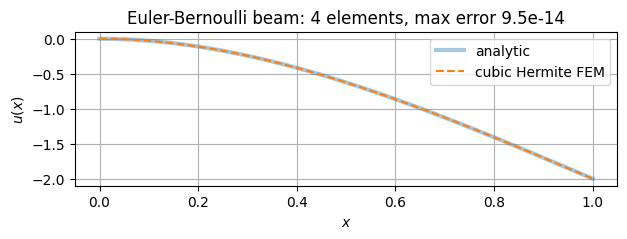

In [21]:
x_plot_d = np.linspace(0, L, 200)

fig, ax = plt.subplots(1, 1, figsize=(7, 2))
ax.plot(x_plot_d, u_exact_d(x_plot_d), lw=3, alpha=0.4, label="analytic")
ax.plot(x_plot_d, u_sol_d(x_plot_d), "--", label="cubic Hermite FEM")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x)$")
ax.set_title(f"Euler-Bernoulli beam: {space_d.basis.n_elements} elements, max error {err_d:.1e}")
ax.grid()
ax.legend()
plt.show()

## Heat equation via method of lines

$$u_t(x,t) = \kappa\, u_{xx}(x,t), \qquad x \in [0, 2\pi) \text{ periodic}$$

Every problem so far has been a steady BVP (or an eigenvalue problem). This is the first transient one, and the first to hand a semi-discrete system to `arc.simulate.odeint` -- the cheapest way to check that `approximation` actually composes with `simulate`.

Discretizing on `FunctionSpace.fourier` (the newest basis in the module, so far only unit-tested) turns this into the simplest possible method-of-lines system: the weak (Galerkin) form is $M\dot c = -\kappa K c$ for mass matrix $M = \Phi^\top\Phi$ and stiffness $K = \Phi_x^\top \Phi_x$, assembled exactly like every other problem here via `basis_matrix`. Because the Fourier basis is (by construction) orthonormal and diagonalizes the Laplacian, $M$ comes out numerically as the identity and $K$ as diagonal with eigenvalues $(k\,\omega)^2$ -- but nothing in the assembly *assumes* that; it's a generic Galerkin residual, same as Problems A-D.

Exact solution: seed a single Fourier mode as the initial condition. Since it's an eigenfunction of the (negative) Laplacian, it stays a pure mode for all time and decays exactly as $e^{-\kappa (k\omega)^2 t}$ -- a closed form to check the ODE solve against directly, no manufacturing required.

In [22]:
n_basis_e = 7
a_e, b_e = 0.0, 2 * np.pi
kappa = 0.3
k_mode = 2  # which cos(k*theta) mode to seed

space_e = FunctionSpace.fourier(n_basis_e, a=a_e, b=b_e, kind="full")

Phi = space_e.basis_matrix()
dPhi = space_e.basis_matrix(deriv=1)
M_e = Phi.T @ Phi  # mass matrix, int phi_i phi_j dtheta
K_e = dPhi.T @ dPhi  # stiffness matrix, int phi'_i phi'_j dtheta


def rhs_e(t, c):
    return np.linalg.solve(M_e, -kappa * (K_e @ c))


mode_idx = 2 * k_mode - 1  # "full" ordering: [1, cos1, sin1, cos2, sin2, ...]
c0_e = np.zeros(n_basis_e)
c0_e[mode_idx] = 1.0

t_span_e = (0.0, 1.0)
t_eval_e = np.linspace(*t_span_e, 5)
c_sol_e = arc.odeint(
    rhs_e, t_span_e, c0_e, t_eval=t_eval_e, atol=1e-10, rtol=1e-9
)
u_sol_e = space_e.function(c_sol_e)

scale_e = (b_e - a_e) / 2
omega_e = np.pi / scale_e
decay_e = np.exp(-kappa * (k_mode * omega_e) ** 2 * t_eval_e)
err_e = np.max(np.abs(c_sol_e[mode_idx] - decay_e))
print(f"max |c_h(t) - exp(-kappa*(k*omega)^2*t)|: {err_e:.3e}")

max |c_h(t) - exp(-kappa*(k*omega)^2*t)|: 1.825e-08


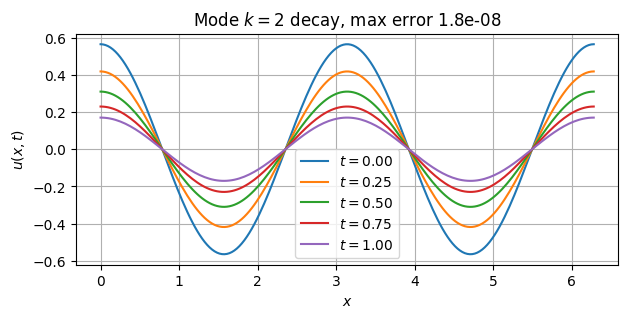

In [23]:
x_plot_e = np.linspace(a_e, b_e, 200)
u_vals_e = u_sol_e(x_plot_e)

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
for i, t in enumerate(t_eval_e):
    ax.plot(x_plot_e, u_vals_e[:, i], label=f"$t={t:.2f}$")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x, t)$")
ax.set_title(f"Mode $k={k_mode}$ decay, max error {err_e:.1e}")
ax.legend()
ax.grid()
plt.show()

## DG advection with an upwind numerical flux

$$u_t + c\,u_x = 0, \qquad x \in [0, 2\pi) \text{ periodic}$$

The semi-discrete DG form, per element, comes from one integration by parts:
$$\int_{\Omega} u_t\,v\,dx = c\int_\Omega u\,v'\,dx - \big[F^*\,v\big]_{\text{interfaces}}$$
where $F^* = c\,u^-$ is the upwind flux (since $c>0$, information comes from the left), built from $u^-$/$u^+$ -- exactly `side="left"`/`side="right"` on the global (broken) basis. A point on an interface is nonzero only in the element that owns it from that side, so `phi_left`/`phi_right` computed once per interface give the whole flux contribution as a rank-one update, including a manual "wrap" pairing the two domain endpoints back together for periodicity (`PiecewiseBasis` itself has no periodic option -- see the "Further test problems" note above).

We use modal (`kind="legendre"`) elements -- an orthogonal per-element basis, the classic choice for DG (e.g. the Runge-Kutta DG formulation of Cockburn and Shu). Building this originally surfaced a real bug: the fused evaluation path in `PiecewiseBasis` didn't forward each element's physical width to a *modal* local basis's own normalization, so this exact space (`kind="legendre"`, `continuity=-1`, more than one element) reconstructed incorrectly. That's now fixed (`Basis._reference_scale_exponent`, applied in `PiecewiseBasis.evaluate_expansion`); the nodal (`kind="lagrange"`) alternative was never affected and gives the same accuracy, confirming the fix rather than working around it.

Exact solution: $u(x,t) = \sin(x - ct)$, an exact traveling wave under periodic advection.

In [ ]:
a_f, b_f = 0.0, 2 * np.pi
n_elements_f = 8
degree_f = 5
c_speed = 1.0

breakpoints_f = np.linspace(a_f, b_f, n_elements_f + 1)
space_f = FunctionSpace.piecewise("legendre", degree_f, breakpoints_f, continuity=-1)

Phi = space_f.basis_matrix()
dPhi = space_f.basis_matrix(deriv=1)
M_f = Phi.T @ Phi.matrix
Kvol_f = dPhi.T @ Phi.matrix  # int u * v' dx


def phi_side(x_pt, side):
    return space_f.basis.evaluate(np.array([x_pt]), side=side, a=a_f, b=b_f)[0]


interior_bps_f = breakpoints_f[1:-1]
phi_left_f = [phi_side(xb, "left") for xb in interior_bps_f]
phi_right_f = [phi_side(xb, "right") for xb in interior_bps_f]

# Periodic wrap: the last element's right end and the first element's left
# end are the same physical point.
phi_left_wrap_f = phi_side(b_f, "left")
phi_right_wrap_f = phi_side(a_f, "right")


def rhs_f(t, c):
    flux = np.zeros_like(c)
    for pl, pr in zip(phi_left_f, phi_right_f):
        f_star = c_speed * (pl @ c)  # upwind: F* = c * u^-
        flux = flux + f_star * (pl - pr)
    f_star_wrap = c_speed * (phi_left_wrap_f @ c)
    flux = flux + f_star_wrap * (phi_left_wrap_f - phi_right_wrap_f)
    return np.linalg.solve(M_f, c_speed * (Kvol_f @ c) - flux)


def u0_f(x):
    return np.sin(x)


u0_fn_f = space_f.project(u0_f)
c0_f = u0_fn_f.coefficients

t_span_f = (0.0, 2.0)
t_eval_f = np.array([0.0, 1.0, 2.0])
c_sol_f = arc.simulate.odeint(
    rhs_f, t_span_f, c0_f, t_eval=t_eval_f, atol=1e-10, rtol=1e-9
)
u_sol_f = space_f.function(c_sol_f)

x_check_f = np.linspace(a_f, b_f, 21, endpoint=False)
err_f = 0.0
for i, t in enumerate(t_eval_f):
    exact = np.sin(x_check_f - c_speed * t)
    err_f = max(err_f, np.max(np.abs(u_sol_f(x_check_f)[:, i] - exact)))
print(f"max |u_h - u_exact| over t in {t_eval_f}: {err_f:.3e}")

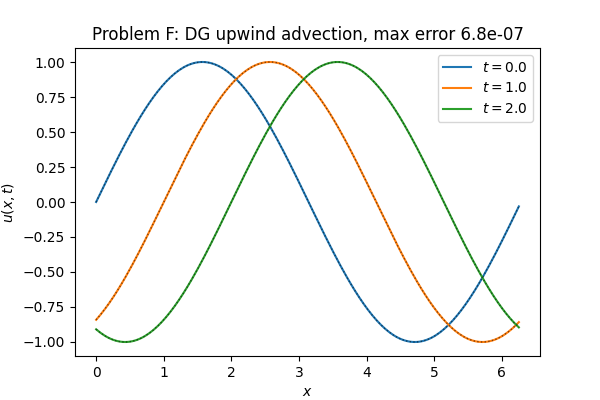

In [25]:
x_plot_f = np.linspace(a_f, b_f, 200, endpoint=False)
u_vals_f = u_sol_f(x_plot_f)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for i, t in enumerate(t_eval_f):
    ax.plot(x_plot_f, u_vals_f[:, i], label=f"$t={t:.1f}$")
    ax.plot(x_plot_f, np.sin(x_plot_f - c_speed * t), "k:", lw=1, alpha=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x, t)$")
ax.set_title(f"Problem F: DG upwind advection, max error {err_f:.1e}")
ax.legend()
plt.show()

## Further test problems

Problems A-C exercise the *shape* of a boundary condition (an endpoint value, an
endpoint derivative, a global constraint) but they're all still 1D, steady, and
scalar-valued. Here's a broader menu, organized by what each one would actually
stress in the design, with a rough read on what's already supported versus what
would need new work.

### Boundary conditions

- **Pure Neumann** ($u'(0) = u'(1) = 0$, no Dirichlet at all). The stiffness matrix
  has a nontrivial null space (the constant function), so the linear system is
  singular unless something pins the mean -- a genuinely different failure mode from
  Problem C's zero-mean *constraint*, since here nothing forces uniqueness unless you
  add it yourself.
- **Robin/mixed** ($a\,u(x_b) + b\,u'(x_b) = g$). Cheap to try -- one row,
  `a*u(x_b) + b*u(x_b, deriv=1) - g`, the same mechanism as Problem C's Neumann row
  but with both terms present at once.
- **Interior interface/jump conditions** -- two materials meeting at a breakpoint,
  continuous value but a flux jump ($k_1 u_1' \neq k_2 u_2'$). `PiecewiseBasis`
  already has breakpoints and one-sided (`side=`) evaluation, originally built for DG
  numerical fluxes -- untested so far for an *interior essential condition* rather
  than a domain-boundary one.
- ~~**Periodic.**~~ `FourierBasis`/`FunctionSpace.fourier` now exist (Problem E uses
  one). `PiecewiseBasis` itself still has no periodic "wrap" option, though -- its
  continuity assembly only merges *interior* breakpoints, never the first DOF back
  to the last (Problem F's DG flux wraps the two domain endpoints by hand instead).

### Different mathematical structure

- ~~**Sturm-Liouville eigenvalue problem**~~
- **Coupled/vector-valued system** (a two-species reaction-diffusion pair, or a
  linear-elasticity bar) -- exercises `Function`'s vector-valued coefficients
  (`(n_basis, m)`) with *different* boundary conditions per component. Row-splicing
  becomes 2D: which `(dof, component)` pairs get overridden.
- **Singularly perturbed convection-diffusion** ($-\epsilon u'' + u' = f$, small
  $\epsilon$) -- a classic boundary-layer problem (Boyd's Rule 6). Also the case that
  actually *needs* mismatched trial/test derivative orders ($\int u' v\,dx$), rather
  than that being hypothetical.
- ~~**4th-order / beam bending** ($u'''' = f$)~~ -- `CubicHermiteBasis` now exists
  and Problem D is exactly this (a cantilever beam, `continuity=1`).
- **Blasius** (semi-infinite, nonlinear, 3rd-order) -- exercises the barely-tested
  `HalfLine`/Laguerre combination.

### Discontinuous Galerkin

~~A linear advection equation ($u_t + c\,u_x = 0$) via DG on `continuity=-1`
elements with an upwind numerical flux at each interface, built from $u^-$/$u^+$ via
`side="left"`/`"right"` evaluation.~~ Problem F, on modal (`kind="legendre"`)
elements -- the classic choice for DG. Building it originally surfaced a real bug in
`PiecewiseBasis`'s fused evaluation path: it didn't forward each element's physical
width to a *modal* local basis's own normalization, so a multi-element
`kind="legendre"`, `continuity=-1` space reconstructed incorrectly (nodal
`kind="lagrange"`/Hermite elements were unaffected, since their shape functions don't
need that normalization). Now fixed via a new `Basis._reference_scale_exponent`
protocol hook, with a regression test
(`test_piecewise.py::TestModalDiscontinuous`) that fails without the fix.

### Transient

- ~~**Heat equation** (linear parabolic)~~ -- Problem E, method of lines via
  `arc.simulate.odeint` on a `FunctionSpace.fourier` space.
- **Wave equation** -- same MOL approach, first-order-in-time reduction, hyperbolic
  instead of parabolic.
- **Viscous Burgers'** -- nonlinear flux plus diffusion, a smooth traveling shock
  layer with known structure. Combines nonlinear residual assembly *and*
  time-stepping in one problem, and on a spectral/`TensorBasis` space would be the
  first thing here to touch dealiasing.

### Candidates for next

1. **Interior interface/jump condition** on the FEM problem -- nearly free given
   `side=` already exists.
2. **Coupled/vector-valued system** -- the 2D row-splicing case, not yet exercised
   by any problem here.
3. **Wave equation** -- the same method-of-lines pattern as Problem E, first-order
   reduction, hyperbolic rather than parabolic.